# Marker Repo

## Loading packages

In [1]:
import marker_repo as mr
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2

## Adding a list

### Settings

In [3]:
REPO_LISTS_PATH = "/mnt/workspace/mkessle/projects/marker_repo/lists"

# The path were the list of marker genes or regions is located
LIST_PATH = "/mnt/workspace/mkessle/projects/marker_repo/dbs/panglao_split/panglao_human_Blood"

# The path were the corresponding metadata file is located
# None, if you like to add the metadata manually
METADATA_PATH = None

### Add metadata

In [4]:
# TODO: whitelists for all metadata input but title
if not METADATA_PATH:
    title = "panglao" # Title is also the file name
    list_type = "celltype" # celltype, cellcycle, mito, gender, blacklist, ...
    year = "2020"
    tissue = "blood"
    organism = "human"
    kind = "genes" # Genes or Regions
    
    # TODO: misc columns
    misc = None # Additional columns like ubiquitousness index
else:
    #TODO: convert yaml file to dictionary
    pass
    
metadata = {"Kind": kind, "Organism": organism, "Tissue": tissue, 
             "Year": year, "List type": list_type, "Title": title}

### Checking

In [5]:
# Checking input files and format of list
mr.checkFiles(LIST_PATH, METADATA_PATH, list_type)

/mnt/workspace/mkessle/projects/marker_repo/dbs/panglao_split/panglao_human_Blood exists.
The format of the list seems correct.


True

### Prepare folders and add the list

In [6]:
mr.addList(REPO_LISTS_PATH, LIST_PATH, metadata)

The file /mnt/workspace/mkessle/projects/marker_repo/lists/genes/human/blood/2020/celltype/panglao already exists.
Do you want to override the existing file?        Enter yes or no: no


'/mnt/workspace/mkessle/projects/marker_repo/lists/genes/human/blood/2020/celltype/panglao'

## Search Marker Repo

In [7]:
# Load DB
df = mr.getDB(REPO_LISTS_PATH)

# Enter keywords
title = None
list_type = "celltype" # celltype, cellcycle, mito, gender, blacklist, ...
year = None
tissue = "blood"
organism = "human"
kind = "genes" # Genes or Regions
misc = None

keywords = {"Kind": kind, "Organism": organism, "Tissue": tissue, 
             "Year": year, "List type": list_type, "Title": title}

# Filter lists
filtered_df = mr.searchDB(df, keywords, exact=False)
filtered_df

# Show paths
paths = mr.getPaths(REPO_LISTS_PATH, filtered_df)

/mnt/workspace/mkessle/projects/marker_repo/lists/genes/human/blood/2020/celltype/panglao
/mnt/workspace/mkessle/projects/marker_repo/lists/genes/human/blood/2022/celltype/hcm
/mnt/workspace/mkessle/projects/marker_repo/lists/genes/human/blood-vessel/2022/celltype/hcm


## Combine Lists

In [8]:
# Combine output from search
combined_df = mr.combineLists(paths)

,Cell type,Marker
0,Erythroblasts,CGA
1,Erythroblasts,GPHa
2,Erythroblasts,GPHA1
3,Erythroblasts,FSHA
4,Erythroblasts,LHA
...,...,...
17280,Endothelial cell,CD31
17281,Endothelial cell,LYVE1
17282,Endothelial cell,LYVE-1
17283,Endothelial cell,NaN


Combined list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/custom_list


## Search list

In [9]:
keywords = {"Cell type": "Fib"}

# Filter lists
filtered_df = mr.searchDB(combined_df, keywords, exact=False)
filtered_df

,Cell type,Marker
0,Fibroblast,COL3A1
1,Fibroblast,COL3A1
2,Fibroblast,THY1
3,Fibroblast,THY1
4,Fibroblast,COL1A1
5,Fibroblast,COL1A1
6,Fibroblast,FAP
7,Fibroblast,FAP
8,Fibroblast,NaN
9,Fibroblast,Pdgfra


## Statistics

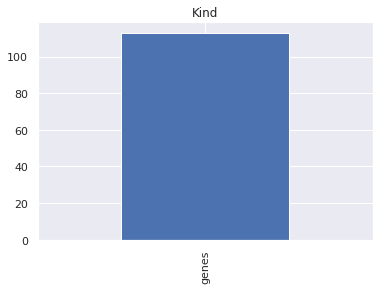

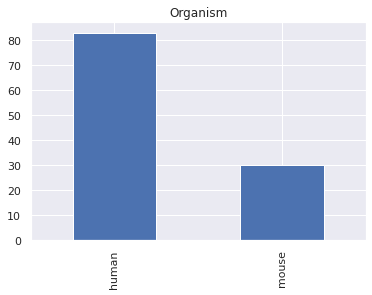

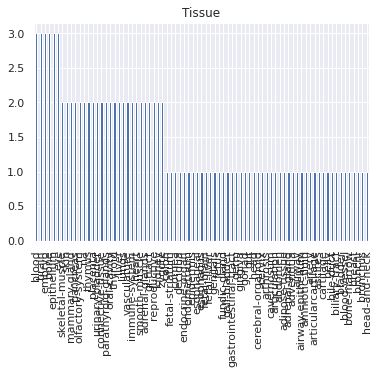

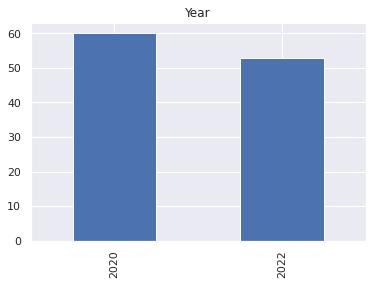

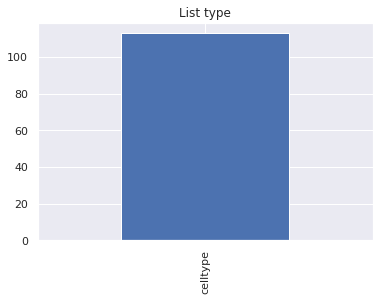

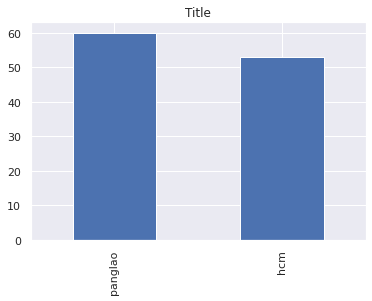

In [10]:
sns.set_style("darkgrid")
sns.set(rc={"figure.dpi": 120, "savefig.dpi": 120})

# Load all lists
df = mr.getDB(REPO_LISTS_PATH)

# Plot statistics
for key in metadata:
    stat_df = df[key].value_counts()
    stat_df.plot(kind='bar', title=key)
    plt.show()

## Convert lists

In [11]:
# TODO